### Libraries

In [32]:
pip install numpy matplotlib torch_incremental_pca

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import time
import pickle
from pathlib import Path
from torch_incremental_pca import IncrementalPCA

# custom wrapper for many cv2 functions
from video import *

### Directories

In [34]:
data_dir = Path("..") / "data"
polygon_dir = Path("..") / "polygons"

In [35]:
# create output directories if they do not already exist
figure_dir = Path("..") / "figures"
for dir in [figure_dir]:
    if not dir.is_dir():
        dir.mkdir(parents=True, exist_ok=True)

if not polygon_dir.is_dir():
    from polygonanalyser import xs_all, ys_all, xs_yb, ys_yb


### Control flags

In [36]:
show_video = 0
load_mask = 1

### Video load and show

In [37]:
# load the video
video_filename = "Video_Test_F2787_125743_01_VIDCKPT_sec.mpg"
video_path = data_dir / video_filename 
cap = cv2.VideoCapture(video_path)

In [38]:
def show_video_with_trackbar():
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    window_name = "flight"

    cv2.namedWindow(window_name)

    # method for setting frame
    def on_trackbar_change(trackbar_value):
        cap.set(cv2.CAP_PROP_POS_FRAMES, trackbar_value)
        return 

    cv2.createTrackbar("...", window_name, 0, total_frames - 1, on_trackbar_change)

    while cap.isOpened():

        current_trackbar_pos = cv2.getTrackbarPos("...", window_name)

        ret, frame = cap.read()
    
        # if frame is read correctly ret is True. ret will be false when video is over
        if not ret:
            print("Can't receive frame (stream end?). Exiting ...")
            break

        # update the trackbar regularly
        current_frame_id = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
        cv2.setTrackbarPos("...", window_name, current_frame_id)

        # gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        cv2.imshow('frame', frame)#, gray)

        # actions to do
        # quit
        if cv2.waitKey(1) == ord('q'):
            break

    cv2.destroyAllWindows()

    
if show_video:
    show_video_with_trackbar()

### Mask creation

In [39]:
if load_mask:
    from mask_creation import get_mask
    mask = get_mask(cap, plot_mask=True)

### Singular frames 

In [40]:
# define bins used for all histograms
bins = np.arange(0, 256, 5)

def normalize_brightness(frame):
    # normalization using LAB frame
    # https://en.wikipedia.org/wiki/CIELAB_color_space
    # L in LAB is "lightness"
    lab_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab_frame)

    # extract the valid l-channel pixels
    valid_l_pixels = l_channel[mask==1].astype(np.float32)

    # normalize brightness channel by mean=255//2, std=50?
    l_mean, l_std = valid_l_pixels.mean(), valid_l_pixels.std()

    normalized_l = (valid_l_pixels - l_mean) / l_std * 50 + 128
    normalized_l = np.clip(normalized_l, 0, 255).astype(np.uint8)
    l_channel[mask==1] = normalized_l

    # merge back
    normalized_LAB = cv2.merge([l_channel, a_channel, b_channel])
    normalized = cv2.cvtColor(normalized_LAB, cv2.COLOR_LAB2BGR)
    return normalized

def channel_histogram(pixels, density=True):
    # get counts (density)
    counts_blue, _ = np.histogram(pixels[:, 0], bins, density=density)
    counts_green, _ = np.histogram(pixels[:, 1], bins, density=density)
    counts_red, _ = np.histogram(pixels[:, 2], bins, density=density)
    return counts_blue, counts_green, counts_red

def plot_frame_and_histogram(frame, histograms):

    ch1, ch2, ch3 = histograms

    fig, axs=plt.subplots(3, 1)

    axs[0].plot(bins[:-1], ch1)
    axs[1].plot(bins[:-1], ch2)
    axs[2].plot(bins[:-1], ch3)

    axs[0].set_title("blue", c="blue")
    axs[1].set_title("green", c="green")
    axs[2].set_title("red", c="red")
    fig.tight_layout()

    fig.savefig(Path("..") / "figures" / "histogram.png")
    plt.close()

    # write the frame itself
    cv2.imwrite(Path("..") / "figures" / "image.png", frame)


def extract_im_and_hist(videocapture, target_frame_index, mask, savefigs=True, searchup=True):
    """
    load a particular frame index in the video capture

    searchup 
    """
    if searchup:
        set_frame(videocapture, target_frame_index)

    ret, frame = cap.read()

    if not ret:
        return 

    # filter the frame and normalize it
    frame_filtered = frame * mask[:, :, None]

    # normalize
    frame_filtered = normalize_brightness(frame_filtered)

    # pick out the valid pixels
    valid_pixels = frame_filtered[mask == 1]

    histograms = channel_histogram(valid_pixels, density=True)
    counts_blue, counts_green, counts_red = histograms

    if savefigs:
        plot_frame_and_histogram(frame_filtered, histograms)
    
    return {
        "counts_blue": counts_blue,
        "counts_green": counts_green,
        "counts_red": counts_red,
    }

# target_frame = 10000
# target_frame = 4000
target_frame = 1000
histogram_dict = extract_im_and_hist(cap, target_frame, mask, savefigs=1)

### Define ice / noice regions 

In [41]:
# the following loops have been used to establish a ice and a no-ice area
target_frame = 10000 - 1000
for addition in range(0, 10000, 10):
    break    
    extract_im_and_hist(cap, target_frame+addition, mask)
    time.sleep(0.05)

target_frame = 0
for addition in range(0, 5000, 100):
    break
    extract_im_and_hist(cap, target_frame+addition, mask=np.ones(frame_shape))
    time.sleep(0.1)

icing_frames = 10000-1000, 10000-1000 + 10000
noicing_frames = 0, 5000

In [42]:
extract_counts = 0

def extract_counts_icing(counts):
    # extract counts from the icing frames
    for i in np.arange(icing_frames[0], icing_frames[1], 100):
        histogram_counts = extract_im_and_hist(cap, i, mask, savefigs=True)
        for key in histogram_counts:
            counts["icing"][key].append(histogram_counts[key])
            # time.sleep(0.1)

def extract_counts_no_icing(counts):
    # extract counts from the no-icing frames
    for i in np.arange(noicing_frames[0], noicing_frames[1], 100):
        histogram_counts = extract_im_and_hist(cap, i, mask, savefigs=True)
        for key in histogram_counts:
            counts["noicing"][key].append(histogram_counts[key])
            # time.sleep(0.1)
    

if extract_counts:
    counts = {
        "icing": {
            "counts_blue": [],
            "counts_green": [],
            "counts_red": []
        },
        "noicing": {
            "counts_blue": [],
            "counts_green": [],
            "counts_red": []
        },
    }
    # populate counts
    extract_counts_icing(counts)
    extract_counts_icing(counts)
    # convert the lists to numpy arrays
    for key in counts:
        for color in counts[key]:
            counts[key][color] = np.array(counts[key][color])

In [43]:
get_average_counts = 0
if get_average_counts:
    average_dist_dir = Path("..") / "average_dist"
    if not average_dist_dir.is_dir(): average_dist_dir.mkdir(parents=True, exist_ok=True)

    # find average histograms and plot them
    figicing, axsicing = plt.subplots(3, 1)
    for i, key in enumerate(counts["icing"].keys()):
        average_count = counts["icing"][key].mean(axis=0)
        np.save(average_dist_dir / ("icing" + key + ".npy"), average_count)
        axsicing[i].plot(bins[:-1], average_count)

    fignoicing, axsnoicing = plt.subplots(3, 1)
    for i, key in enumerate(counts["noicing"].keys()):
        average_count = counts["noicing"][key].mean(axis=0)
        np.save(average_dist_dir / ("noicing" + key + ".npy"), average_count)
        axsnoicing[i].plot(bins[:-1], average_count)

    # formatting
    for i, color in enumerate(["blue", "green", "red"]):
        axsicing[i].set_title(color, c=color)
        axsnoicing[i].set_title(color, c=color)

    figicing.suptitle("Icing")
    fignoicing.suptitle("No icing")
    figicing.tight_layout()
    fignoicing.tight_layout()
    figicing.savefig(figure_dir / "Mean icing histogram")
    fignoicing.savefig(figure_dir / "Mean no-icing histogram")

    plt.close("all")


In [44]:

Lab = np.ones((100, 100, 3), dtype=np.uint8)
H = 40 * 255 // 360
H = 20
S = 150
V = 225
Lab[:, :, 0] = H * np.ones((100, 100))
Lab[:, :, 1] = S * np.ones((100, 100))
Lab[:, :, 2] = V * np.ones((100, 100))

BGR = change_color_representation(Lab, cv2.COLOR_HSV2BGR)
cv2.imwrite(figure_dir / "image.png", BGR)
print(f"{H = }")

H = 20


### Test iceness index method

In [45]:
def icenessindex(normalized_filtered_frame):
    # H_lower, H_upper = 0, 3
    # S_lower, S_upper = 0, 3.0  
    # V_lower, V_upper = 0, 7.75
    # isice = (H < H_upper and S < S_upper and V < V_upper)

    ICE_threshold = 0.095
    # change representation
    HSV = cv2.cvtColor(normalized_filtered_frame, cv2.COLOR_BGR2HSV)

    H = HSV[:,:, 0].mean()
    S = HSV[:,:, 1].mean()
    V = HSV[:,:, 2].mean()

    # iceness = 1/(H + S + V)
    iceness = 1/(S + V)
    isice = iceness>ICE_threshold
    # return isice, iceness
    return iceness, isice, H, S, V

In [46]:
run_live_tester = 1

def live_tester(start):
    # open video at start
    i = start
    cap.set(cv2.CAP_PROP_POS_FRAMES, i) # search up the frame
    ret, frame = cap.read()

    fig, axs=plt.subplots(5, 1)
    axs[0].set_title("Iceness")
    axs[1].set_title("Ice indicator")
    plt.close("all")
    ice_history = []
    icenesshistory = []
    Hs = []
    Ss  = []
    Vs = []
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        cv2.imshow("..", frame)

        # filter the frame and normalize it
        frame_filtered = frame * mask[:, :, None]

        # normalize
        frame_filtered = normalize_brightness(frame_filtered)

        iceness, isice, H, S, V = icenessindex(frame_filtered)

        ice_history.append(isice * 1.0 if isice else 0.0) 
        icenesshistory.append(iceness)

        Hs.append(H)
        Ss.append(S)
        Vs.append(V)

        axs[0].plot(icenesshistory, c="k")
        axs[1].plot(ice_history, c="k")
        axs[2].plot(Hs)
        axs[3].plot(Ss)
        axs[4].plot(Vs)

        
        fig.savefig(figure_dir / "yellow history.png")

        key = cv2.waitKey(1)
        if key == ord("q"):
            break

        if key == ord("i"):
            for i in range(len(axs)):
                axs[i].axvline(len(icenesshistory)-1)

        elif key == ord(" "):
            k = cv2.waitKey(0)
            if k == ord(" "):
                continue
            elif k == ord("q"):
                break
        increase = 100
        for _ in range(increase - 1):
            # grab but dont decdoe
            cap.grab()


        i += increase
    cv2.destroyAllWindows()
    
if run_live_tester:
    live_tester(0)

OSError: [Errno 28] No space left on device

### Use iceness index to split video into ice / no-ice

Using the regions of interest, we should be able to split the original video into two videos 

In [ ]:
outputvideos_dir = Path("..") / "outputvideos"
if not outputvideos_dir.is_dir(): outputvideos_dir.mkdir(parents=True, exist_ok=True)
output_icing_path = outputvideos_dir / ("icing_" + video_filename)
output_noicing_path = outputvideos_dir / ("noicing_" + video_filename)
split_video_into_ice_noice = 0



def split_into_ice_noice(videocapture, output_icing, output_noicing, increase=100, num_frames = 1000, ):
    # open video at beginning 
    i = 0
    videocapture.set(cv2.CAP_PROP_POS_FRAMES, i) # search up the frame
    ret, frame = cap.read()

    frame_indicies_ice = []
    frame_indicies_noice = []

    num_dp = 1
    while cap.isOpened():

        ret, frame = videocapture.read()
        if not ret:
            break

        frame_filtered = frame * mask[:, :, None]

        frame_filtered_normalized = normalize_brightness(frame_filtered)

        _, isice = icenessindex(frame_filtered_normalized)

        if isice:
            output_icing.write(frame)
            frame_indicies_ice.append(i)
        else:
            output_noicing.write(frame)
            frame_indicies_noice.append(i)


        if num_dp == num_frames and num_frames:
            break

        for _ in range(increase):
            videocapture.grab()
        num_dp += 1
        i += increase

    output_icing.release()
    output_noicing.release()
    cv2.destroyAllWindows()
    frame_indicies_ice = np.array(frame_indicies_ice)
    frame_indicies_noice = np.array(frame_indicies_noice)
    np.save(outputvideos_dir / "frame_indicies_ice.npy", frame_indicies_ice)
    np.save(outputvideos_dir / "frame_indicies_noice.npy", frame_indicies_noice)

if split_video_into_ice_noice:

    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
    ret, frame = cap.read()
    frame_shape = frame.shape
    width, height = frame_shape[1], frame_shape[0]
    # from
    # https://learnopencv.com/reading-and-writing-videos-using-opencv/
    output_icing = cv2.VideoWriter(output_icing_path,
                                cv2.VideoWriter_fourcc(*'XVID'), 20, (width, height))
    output_noicing = cv2.VideoWriter(output_noicing_path,
                                    cv2.VideoWriter_fourcc(*'XVID'), 20, (width, height))

    split_into_ice_noice(cap, output_icing, output_noicing, 100, 0)




In [ ]:
frame_indicies_ice = np.load(outputvideos_dir / "frame_indicies_ice.npy")
frame_indicies_noice = np.load(outputvideos_dir / "frame_indicies_noice.npy")

In [ ]:
show_noicing = 0
show_icing = 1


cap_noicing = cv2.VideoCapture(output_noicing_path)
cap_icing = cv2.VideoCapture(output_icing_path)

total_frames_noicing = int(cap_noicing.get(cv2.CAP_PROP_FRAME_COUNT))
total_frames_icing = int(cap_icing.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"{total_frames_noicing = }")
print(f"{total_frames_icing = }")

cap_noicing.set(cv2.CAP_PROP_POS_FRAMES, 0)


def show_noicing_video():
    while cap_noicing.isOpened():
        ret, frame = cap_noicing.read()

        if not ret:
            break

        cv2.imshow("No Icing", frame)

        key = cv2.waitKey(0)
        if key == ord("q"):
            break

def show_icing_video():
    cap_icing.set(cv2.CAP_PROP_POS_FRAMES, 0)
    i = 0
    while cap_icing.isOpened():
        ret, frame = cap_icing.read()

        if not ret:
            break

        # if i == total_frames_icing // 2:
        #     break

        cv2.imshow("Icing", frame)

        key = cv2.waitKey(0)
        if key == ord("q"):
            break
        i+=1


if show_noicing:
    show_noicing_video()
if show_icing:
    show_icing_video()

cv2.destroyAllWindows()

total_frames_noicing = 470
total_frames_icing = 629


In [ ]:
cap_ice = cv2.VideoCapture(output_icing_path)
total_frames_ice = int(cap_ice.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Loaded video with {total_frames_ice} frames")

Loaded video with 629 frames


In [ ]:
print(f"{mask.shape = }")
mask_height, mask_width = mask.shape
# make an array of all the pixels with ice
n_frames = 629//2
pixels_ice = np.zeros((n_frames, mask.sum(), 3), dtype=np.uint8)
cap_ice.set(cv2.CAP_PROP_POS_FRAMES, 0)   
i = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break    
    frame = frame * mask[:, :, None]   
    frame = normalize_brightness(frame)
    pixels = frame[mask==1]
    pixels_ice[i, :, 0] = pixels[:, 0]
    pixels_ice[i, :, 1] = pixels[:, 1]
    pixels_ice[i, :, 2] = pixels[:, 2]

    if i == n_frames - 1:
        break
    i += 1


pixels_ice = np.array(pixels_ice)#.reshape((-1, 3))
pixels_ice_flat = pixels_ice.reshape((n_frames, -1))
sample_size = pixels_ice.shape[1]


mask.shape = (720, 1280)


KeyboardInterrupt: 

In [ ]:
n_components = 2
ipca = IncrementalPCA(n_components)
ipca.fit(pixels_ice_flat)

KeyboardInterrupt: 

In [ ]:
components = ipca.components_.reshape((n_components, sample_size, 3))
print(f"{components.shape = }")


components.shape = torch.Size([2, 51585, 3])


In [ ]:
reduced = ipca.transform(pixels_ice_flat)


reduced.shape = torch.Size([314, 2])


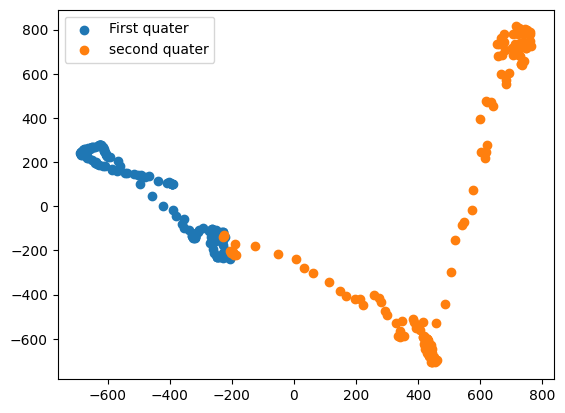

In [ ]:

print(f"{reduced.shape = }")
fig, ax = plt.subplots()
ax.scatter(reduced[:-len(reduced[:, 0])//2, 0], 
           reduced[:-len(reduced[:, 0])//2, 1], label="First quater")
ax.scatter(reduced[len(reduced[:, 0])//2:, 0], 
           reduced[len(reduced[:, 0])//2:, 1], label="second quater")
ax.legend()